# Notebook 04 — Analyse du Data Drift

**Projet 8 — Confirmez vos compétences en MLOps · Yohan Parent**

## Objectif

Détecter et interpréter la dérive entre les données ayant servi à entraîner
le modèle de scoring (**référence**, projet 6) et les données réellement
soumises à l'API en production (**courant**, collectées via les logs).

## Démarche

1. Charger les deux jeux : référence (entraînement) et production (logs API)
2. Analyser la santé opérationnelle : latence, taux d'erreur, débit
3. Détecter le **data drift** sur les features (Evidently + PSI)
4. Détecter le **prediction drift** sur les scores
5. Croiser drift et **importance des variables** (SHAP du projet 6)
6. Conclure : points de vigilance et plan d'action

## Rappel : les deux types de dérive

| | Data drift | Concept drift |
|---|---|---|
| Ce qui change | La distribution des entrées P(X) | La relation P(y\|X) |
| Détectable sans étiquettes | Oui | Non |
| Détecté ici | **Oui** | Non (les défauts ne sont connus que des mois plus tard) |

In [1]:
# =====================================================================
# Notebook 04 - Analyse du Data Drift
# =====================================================================
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
sns.set_theme(style="whitegrid")

RACINE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

# --- 1. Le jeu de REFERENCE : les donnees d'entrainement du projet 6 ---
reference = pd.read_parquet(RACINE / "data" / "reference" / "reference.parquet")
print(f"Reference (entrainement projet 6) : {reference.shape[0]:,} lignes "
      f"x {reference.shape[1]} colonnes")

# --- 2. Le jeu COURANT : les logs de production de l'API ---
logs = pd.read_parquet(RACINE / "monitoring" / "production_logs.parquet")
print(f"Production (logs API)             : {logs.shape[0]:,} predictions")
print(f"Periode                           : {logs['timestamp'].min()} "
      f"-> {logs['timestamp'].max()}")

# --- 3. Les metadonnees du modele (seuil, features, metriques du P6) ---
metadata = json.loads((RACINE / "models" / "metadata.json").read_text(encoding="utf-8"))
SEUIL = metadata["threshold"]
FEATURES = metadata["features"]
print(f"\nModele v{metadata['model_version']} | seuil metier = {SEUIL} "
      f"| {len(FEATURES)} features")
print(f"Metriques du projet 6 : {metadata['metriques_projet6']}")

Reference (entrainement projet 6) : 20,000 lignes x 636 colonnes
Production (logs API)             : 1,781 predictions
Periode                           : 2026-08-27 05:58:26.542000+00:00 -> 2026-08-27 07:54:07.748000+00:00

Modele v2 | seuil metier = 0.09 | 635 features
Metriques du projet 6 : {'AUC_valid': 0.785482055874041, 'cout_metier_optimal': 29968.0, 'recall_defaut_optimal': 0.6719033232628399}


## 1. Santé opérationnelle de l'API

Avant de parler de dérive statistique, on vérifie que le service fonctionne :
latence, taux d'erreur, volume. C'est le premier réflexe en production —
un drift détecté alors que l'API renvoie 40 % d'erreurs n'a aucun sens.

SANTE OPERATIONNELLE
  Predictions servies    : 1,781
  Erreurs                : 140  (7.29 %)
  Latence totale p50     : 0.72 ms
  Latence totale p95     : 4.70 ms   <- SLO cible : < 100 ms
  Latence totale p99     : 6.27 ms
  Inference pure p95     : 0.384 ms
  Part du modele dans la latence : 8.2 %

  Repartition des erreurs :
status  error_type      
404     http_error            7
413     http_error            6
422     validation_error    127


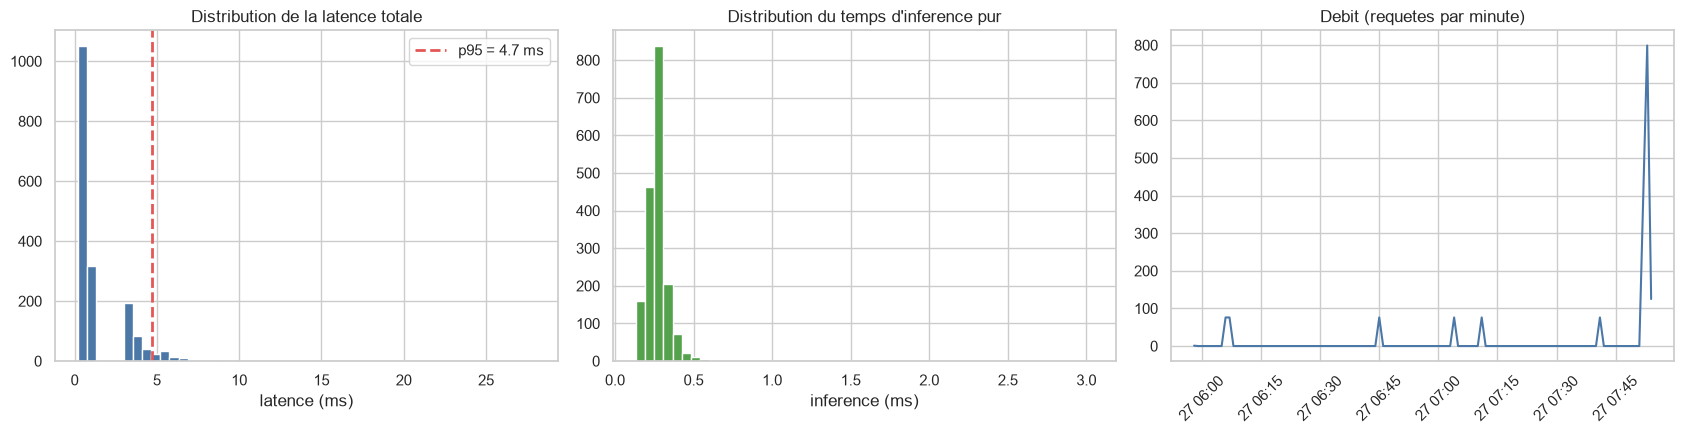

In [2]:
# --- Metriques operationnelles ---
p50 = logs["latency_ms"].quantile(0.50)
p95 = logs["latency_ms"].quantile(0.95)
p99 = logs["latency_ms"].quantile(0.99)
inf_p95 = logs["inference_ms"].quantile(0.95)

chemin_erreurs = RACINE / "monitoring" / "production_logs_errors.parquet"
erreurs = pd.read_parquet(chemin_erreurs) if chemin_erreurs.exists() else pd.DataFrame()
n_total = len(logs) + len(erreurs)
taux_erreur = len(erreurs) / n_total if n_total else 0.0

print("=" * 60)
print("SANTE OPERATIONNELLE")
print("=" * 60)
print(f"  Predictions servies    : {len(logs):,}")
print(f"  Erreurs                : {len(erreurs):,}  ({100 * taux_erreur:.2f} %)")
print(f"  Latence totale p50     : {p50:.2f} ms")
print(f"  Latence totale p95     : {p95:.2f} ms   <- SLO cible : < 100 ms")
print(f"  Latence totale p99     : {p99:.2f} ms")
print(f"  Inference pure p95     : {inf_p95:.3f} ms")
print(f"  Part du modele dans la latence : {100 * inf_p95 / p95:.1f} %")

if not erreurs.empty:
    print("\n  Repartition des erreurs :")
    print(erreurs.groupby(["status", "error_type"]).size().to_string())

# --- Graphiques ---
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].hist(logs["latency_ms"], bins=50, color="#4C78A8", edgecolor="white")
axes[0].axvline(p95, color="#E45756", ls="--", lw=2, label=f"p95 = {p95:.1f} ms")
axes[0].set_title("Distribution de la latence totale")
axes[0].set_xlabel("latence (ms)"); axes[0].legend()

axes[1].hist(logs["inference_ms"], bins=50, color="#54A24B", edgecolor="white")
axes[1].set_title("Distribution du temps d'inference pur")
axes[1].set_xlabel("inference (ms)")

par_heure = logs.set_index("timestamp").resample("1min").size()
axes[2].plot(par_heure.index, par_heure.values, color="#4C78A8")
axes[2].set_title("Debit (requetes par minute)")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(RACINE / "monitoring" / "sante_operationnelle.png", dpi=130,
            bbox_inches="tight")
plt.show()

## 2. Reconstituer la matrice des features de production

Les logs stockent les features sous forme de dictionnaire JSON, une clé par
feature renseignée. On les « déplie » en un DataFrame comparable à la
référence, colonne par colonne.

**Point de vigilance :** on ne compare que les colonnes **communes et
suffisamment renseignées**. Comparer une colonne présente dans 2 % des
requêtes n'a aucun sens statistique.

In [3]:
# --- Deplier le dictionnaire de features en colonnes ---
courant = pd.json_normalize(logs["features"])
print(f"Features presentes dans les logs : {courant.shape[1]}")

# On ne garde que les colonnes renseignees dans au moins 50 % des requetes
taux_remplissage = courant.notna().mean()
colonnes_fiables = taux_remplissage[taux_remplissage >= 0.5].index.tolist()

# ... et communes avec la reference
colonnes_communes = [c for c in colonnes_fiables if c in reference.columns]
print(f"Colonnes suffisamment renseignees et communes : {len(colonnes_communes)}")

# Pour un rapport lisible, on se concentre sur les variables METIER
# interpretables : c'est ce qui parlera a Chloe et aux equipes risque.
VARIABLES_METIER = [
    "AMT_INCOME_TOTAL", "AMT_CREDIT", "AMT_ANNUITY", "AMT_GOODS_PRICE",
    "DAYS_BIRTH", "DAYS_EMPLOYED", "DAYS_REGISTRATION", "DAYS_ID_PUBLISH",
    "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
    "CNT_CHILDREN", "CNT_FAM_MEMBERS", "REGION_POPULATION_RELATIVE",
    "PAYMENT_RATE", "ANNUITY_INCOME_PERC", "INCOME_CREDIT_PERC",
    "DAYS_EMPLOYED_PERC", "INCOME_PER_PERSON",
]
colonnes_analyse = [c for c in VARIABLES_METIER if c in colonnes_communes]

# Complement : les colonnes les plus renseignees, jusqu'a 30 au total
autres = [c for c in colonnes_communes if c not in colonnes_analyse]
colonnes_analyse += autres[: max(0, 30 - len(colonnes_analyse))]

print(f"Colonnes retenues pour l'analyse de drift : {len(colonnes_analyse)}")
print(colonnes_analyse)

ref_analyse = reference[colonnes_analyse].astype("float64")
cur_analyse = courant[colonnes_analyse].astype("float64")
print(f"\nReference : {ref_analyse.shape}   Courant : {cur_analyse.shape}")

Features presentes dans les logs : 636
Colonnes suffisamment renseignees et communes : 479
Colonnes retenues pour l'analyse de drift : 30
['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'CNT_CHILDREN', 'CNT_FAM_MEMBERS', 'REGION_POPULATION_RELATIVE', 'PAYMENT_RATE', 'ANNUITY_INCOME_PERC', 'INCOME_CREDIT_PERC', 'DAYS_EMPLOYED_PERC', 'INCOME_PER_PERSON', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION']

Reference : (20000, 30)   Courant : (1781, 30)


## 3. Détection du data drift avec Evidently

**Evidently** applique automatiquement le test statistique adapté à chaque
colonne :

| Situation | Test appliqué | Seuil |
|---|---|---|
| Numérique, ≤ 1000 lignes | Kolmogorov–Smirnov | p-value < 0,05 |
| Numérique, > 1000 lignes | Distance de Wasserstein normalisée | > 0,1 |
| Catégoriel, ≤ 1000 lignes | χ² | p-value < 0,05 |
| Catégoriel, > 1000 lignes | Jensen-Shannon | > 0,1 |

**Pourquoi ce basculement ?** Sur de gros échantillons, les tests d'hypothèse
deviennent hypersensibles : ils détectent des écarts minuscules et sans
conséquence pratique. Les mesures de distance, elles, quantifient une
**amplitude** et restent interprétables quelle que soit la taille.

**Verdict global.** Evidently déclare le jeu « en dérive » quand **plus de
50 %** des colonnes dérivent (paramètre `drift_share`). C'est un seuil
volontairement conservateur : on peut donc avoir 30 % de colonnes en dérive
avec un verdict global négatif, et ce n'est pas une contradiction. Le verdict
par colonne reste le plus informatif.

In [4]:
from evidently import Report, Dataset, DataDefinition
from evidently.presets import DataDriftPreset

# --- Declaration du type des colonnes ---
# Toutes nos features sont numeriques (le one-hot du projet 6 a produit
# des colonnes 0/1, que l'on traite comme numeriques).
definition = DataDefinition(numerical_columns=list(ref_analyse.columns))

jeu_reference = Dataset.from_pandas(ref_analyse, data_definition=definition)
jeu_courant = Dataset.from_pandas(cur_analyse, data_definition=definition)

# --- Execution du rapport ---
rapport = Report([DataDriftPreset()])
resultat = rapport.run(current_data=jeu_courant, reference_data=jeu_reference)

# --- Export HTML interactif (a joindre aux livrables) ---
dossier_rapports = RACINE / "monitoring" / "reports"
dossier_rapports.mkdir(parents=True, exist_ok=True)
chemin_html = dossier_rapports / "data_drift_report.html"
resultat.save_html(str(chemin_html))
print(f"Rapport HTML : {chemin_html}")

Rapport HTML : C:\Users\Shadow\Documents\OC\PROJET 8\p8-scoring-api\monitoring\reports\data_drift_report.html


In [5]:
def extraire_drift(resultat) -> tuple[dict, pd.DataFrame]:
    """Transforme un resultat Evidently 0.7 en (resume, tableau par colonne).

    La structure renvoyee par .dict() est une liste plate de metriques :
      - une metrique 'DriftedColumnsCount' : le verdict global
      - une metrique 'ValueDrift' par colonne : le detail
    Chaque entree porte un 'config' decrivant la colonne, la methode et le
    seuil, et une 'value' qui est le score de derive.
    """
    donnees = resultat.dict()
    resume: dict = {}
    lignes: list[dict] = []

    for metrique in donnees["metrics"]:
        config = metrique.get("config", {})
        type_metrique = config.get("type", "")

        if type_metrique.endswith("DriftedColumnsCount"):
            valeur = metrique["value"]
            resume = {
                "colonnes_en_derive": int(valeur["count"]),
                "part_en_derive": float(valeur["share"]),
                "seuil_du_jeu": float(config.get("drift_share", 0.5)),
            }

        elif type_metrique.endswith("ValueDrift"):
            score = float(metrique["value"])
            seuil = float(config["threshold"])
            methode = config["method"]
            # Un test base sur une p-value declare la derive quand le score
            # est SOUS le seuil ; une distance, quand il est AU-DESSUS.
            est_p_value = (methode.lower().startswith(("k-s", "chi"))
                           or "p_value" in methode.lower())
            lignes.append({
                "variable": config["column"],
                "test": methode,
                "score": round(score, 4),
                "seuil": seuil,
                "derive": (score < seuil) if est_p_value else (score > seuil),
            })

    tableau = pd.DataFrame(lignes).sort_values(
        ["derive", "score"], ascending=[False, False])
    resume["colonnes_analysees"] = len(tableau)
    resume["derive_du_jeu"] = resume["part_en_derive"] > resume["seuil_du_jeu"]
    return resume, tableau


global_, tableau = extraire_drift(resultat)

print("=" * 60)
print("VERDICT GLOBAL DU DATA DRIFT")
print("=" * 60)
print(f"  Colonnes analysees     : {global_['colonnes_analysees']}")
print(f"  Colonnes en derive     : {global_['colonnes_en_derive']}")
print(f"  Part en derive         : {100 * global_['part_en_derive']:.1f} %")
print(f"  Seuil d'alerte du jeu  : {100 * global_['seuil_du_jeu']:.0f} %")
print(f"  DERIVE DU JEU DETECTEE : {global_['derive_du_jeu']}")

print(f"\nVariables en derive : {tableau['derive'].sum()} / {len(tableau)}\n")
display(tableau.head(20))

tableau.to_csv(RACINE / "monitoring" / "drift_par_variable.csv", index=False)

VERDICT GLOBAL DU DATA DRIFT
  Colonnes analysees     : 30
  Colonnes en derive     : 7
  Part en derive         : 23.3 %
  Seuil d'alerte du jeu  : 50 %
  DERIVE DU JEU DETECTEE : False

Variables en derive : 7 / 30



,variable,test,score,seuil,derive
9,EXT_SOURCE_3,Wasserstein distance (normed),0.2543,0.1,True
4,DAYS_BIRTH,Wasserstein distance (normed),0.2133,0.1,True
8,EXT_SOURCE_2,Wasserstein distance (normed),0.1966,0.1,True
2,AMT_ANNUITY,Wasserstein distance (normed),0.1402,0.1,True
13,PAYMENT_RATE,Wasserstein distance (normed),0.1341,0.1,True
5,DAYS_EMPLOYED,Wasserstein distance (normed),0.1126,0.1,True
7,DAYS_ID_PUBLISH,Wasserstein distance (normed),0.1117,0.1,True
14,ANNUITY_INCOME_PERC,Wasserstein distance (normed),0.0917,0.1,False
3,AMT_GOODS_PRICE,Wasserstein distance (normed),0.0839,0.1,False
1,AMT_CREDIT,Wasserstein distance (normed),0.0727,0.1,False


## 4. Le PSI — la mesure de référence du scoring bancaire

Le **Population Stability Index** est le standard historique du secteur du
crédit. Contrairement à une p-value, il mesure une **amplitude** stable
quelle que soit la taille de l'échantillon, avec une grille d'interprétation
universellement comprise par les équipes risque :

| PSI | Interprétation | Action |
|---|---|---|
| < 0,10 | Population stable | Aucune |
| 0,10 – 0,25 | Dérive modérée | Surveiller, investiguer |
| > 0,25 | Dérive importante | Envisager un ré-entraînement |

On l'implémente à la main : c'est dix lignes, et cela montre qu'on comprend
la mesure au lieu de l'appeler en boîte noire.

In [6]:
def calculer_psi(reference: pd.Series, courant: pd.Series,
                 n_classes: int = 10) -> float:
    """Population Stability Index entre deux distributions.

    On decoupe la reference en deciles, on compare les parts de population
    dans chaque classe, et on somme les ecarts ponderes logarithmiquement.

    PSI = somme_i (part_cur_i - part_ref_i) * ln(part_cur_i / part_ref_i)
    """
    ref = reference.dropna()
    cur = courant.dropna()
    if len(ref) < 20 or len(cur) < 20:
        return np.nan

    # Bornes construites sur la REFERENCE (c'est la population de controle)
    bornes = np.unique(np.quantile(ref, np.linspace(0, 1, n_classes + 1)))
    if len(bornes) < 3:
        return 0.0
    bornes[0], bornes[-1] = -np.inf, np.inf

    part_ref = np.histogram(ref, bins=bornes)[0] / len(ref)
    part_cur = np.histogram(cur, bins=bornes)[0] / len(cur)

    # Epsilon : evite ln(0) et la division par zero quand une classe est vide
    eps = 1e-6
    part_ref = np.clip(part_ref, eps, None)
    part_cur = np.clip(part_cur, eps, None)

    return float(np.sum((part_cur - part_ref) * np.log(part_cur / part_ref)))


def interpreter_psi(psi: float) -> str:
    if np.isnan(psi):
        return "non calculable"
    if psi < 0.10:
        return "stable"
    if psi < 0.25:
        return "derive moderee"
    return "DERIVE IMPORTANTE"


psi_resultats = pd.DataFrame([
    {
        "variable": col,
        "psi": round(calculer_psi(ref_analyse[col], cur_analyse[col]), 4),
        "moy_reference": round(float(ref_analyse[col].mean()), 3),
        "moy_production": round(float(cur_analyse[col].mean()), 3),
    }
    for col in colonnes_analyse
])
psi_resultats["variation_%"] = round(
    100 * (psi_resultats["moy_production"] - psi_resultats["moy_reference"])
    / psi_resultats["moy_reference"].replace(0, np.nan), 1)
psi_resultats["interpretation"] = psi_resultats["psi"].apply(interpreter_psi)
psi_resultats = psi_resultats.sort_values("psi", ascending=False)

print("=" * 80)
print("PSI PAR VARIABLE (trie par amplitude de derive)")
print("=" * 80)
display(psi_resultats.head(20))

print(f"\n  Variables stables            : {(psi_resultats['psi'] < 0.10).sum()}")
print(f"  Derive moderee (0.10-0.25)   : "
      f"{psi_resultats['psi'].between(0.10, 0.25).sum()}")
print(f"  Derive importante (> 0.25)   : {(psi_resultats['psi'] > 0.25).sum()}")

psi_resultats.to_csv(RACINE / "monitoring" / "psi_par_variable.csv", index=False)

PSI PAR VARIABLE (trie par amplitude de derive)


,variable,psi,moy_reference,moy_production,variation_%,interpretation
9,EXT_SOURCE_3,0.1502,0.512,0.464,-9.4,derive moderee
8,EXT_SOURCE_2,0.1136,0.515,0.484,-6.0,derive moderee
0,AMT_INCOME_TOTAL,0.0816,173985.144,186865.592,7.4,stable
4,DAYS_BIRTH,0.0707,-16047.397,-15118.007,-5.8,stable
12,REGION_POPULATION_RELATIVE,0.0524,0.021,0.021,0.0,stable
2,AMT_ANNUITY,0.0448,27116.249,28965.314,6.8,stable
13,PAYMENT_RATE,0.0436,0.053,0.056,5.7,stable
7,DAYS_ID_PUBLISH,0.0406,-3008.850,-3176.730,5.6,stable
5,DAYS_EMPLOYED,0.0399,-2375.032,-2162.307,-9.0,stable
16,DAYS_EMPLOYED_PERC,0.0339,0.156,0.158,1.3,stable



  Variables stables            : 28
  Derive moderee (0.10-0.25)   : 2
  Derive importante (> 0.25)   : 0


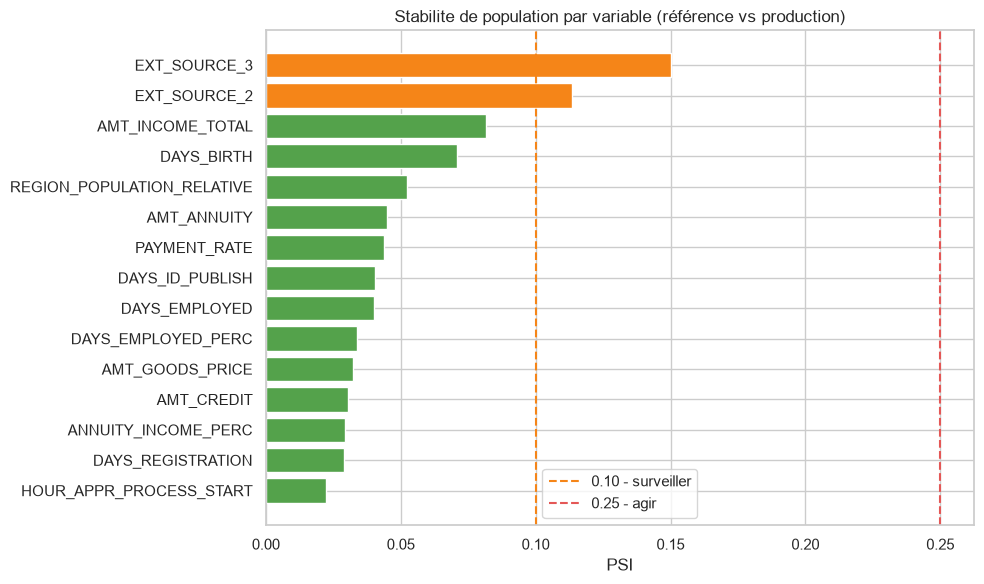

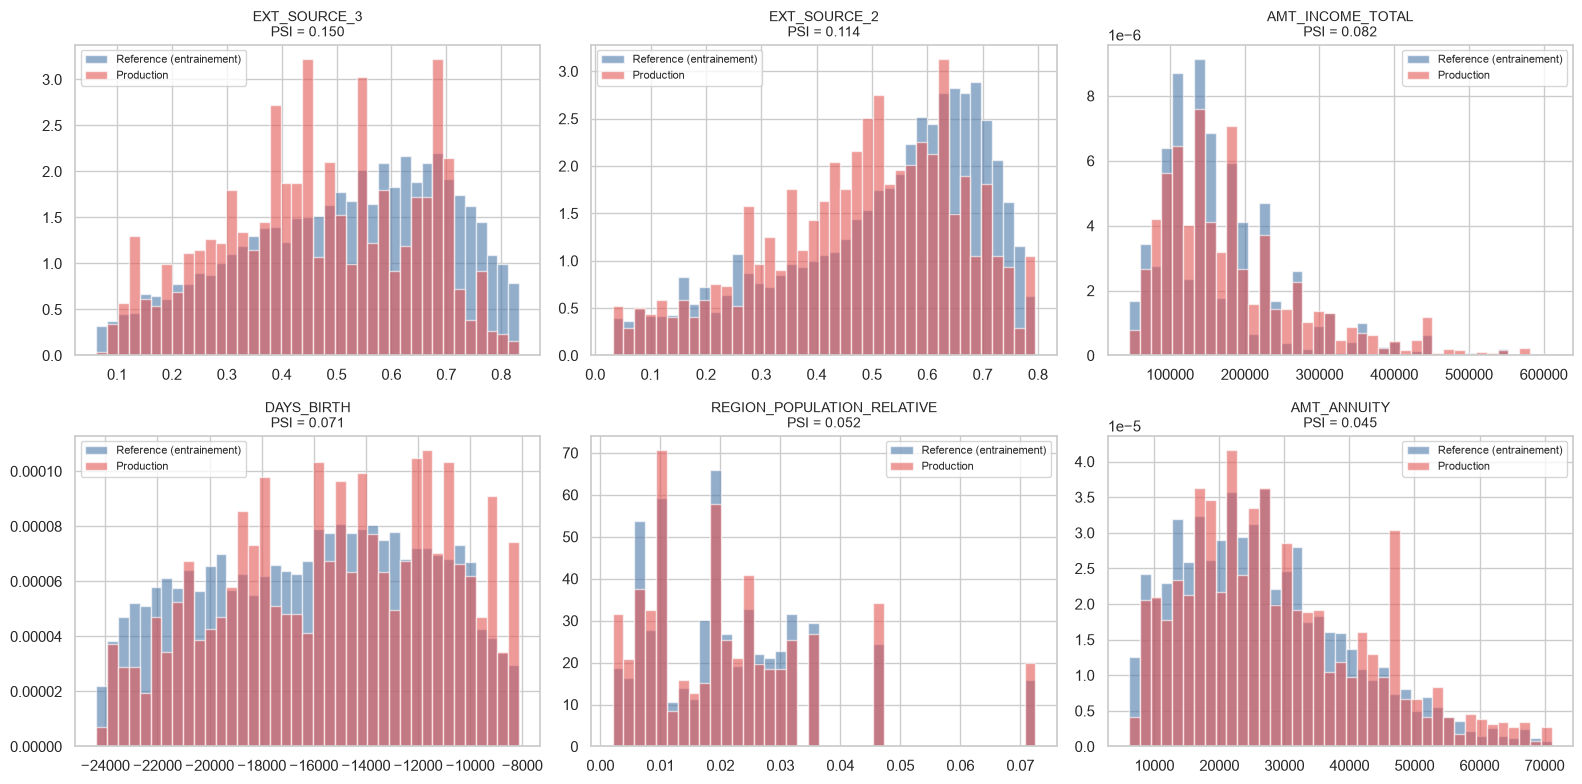

In [7]:
# --- Graphique 1 : PSI par variable ---
top = psi_resultats.head(15).sort_values("psi")
couleurs = ["#54A24B" if p < 0.10 else "#F58518" if p < 0.25 else "#E45756"
            for p in top["psi"]]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top["variable"], top["psi"], color=couleurs)
ax.axvline(0.10, color="#F58518", ls="--", lw=1.5, label="0.10 - surveiller")
ax.axvline(0.25, color="#E45756", ls="--", lw=1.5, label="0.25 - agir")
ax.set_xlabel("PSI")
ax.set_title("Stabilite de population par variable (référence vs production)")
ax.legend()
plt.tight_layout()
plt.savefig(RACINE / "monitoring" / "psi_par_variable.png", dpi=130,
            bbox_inches="tight")
plt.show()

# --- Graphique 2 : distributions superposees des 6 plus fortes derives ---
pires = psi_resultats.head(6)["variable"].tolist()
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.ravel(), pires):
    ref_valeurs = ref_analyse[col].dropna()
    cur_valeurs = cur_analyse[col].dropna()
    # On coupe les 1 % extremes pour un graphique lisible
    bas = min(ref_valeurs.quantile(0.01), cur_valeurs.quantile(0.01))
    haut = max(ref_valeurs.quantile(0.99), cur_valeurs.quantile(0.99))
    bins = np.linspace(bas, haut, 40)
    ax.hist(ref_valeurs, bins=bins, alpha=0.6, density=True,
            label="Reference (entrainement)", color="#4C78A8")
    ax.hist(cur_valeurs, bins=bins, alpha=0.6, density=True,
            label="Production", color="#E45756")
    psi = psi_resultats.loc[psi_resultats["variable"] == col, "psi"].iloc[0]
    ax.set_title(f"{col}\nPSI = {psi:.3f}", fontsize=10)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(RACINE / "monitoring" / "distributions_derive.png", dpi=130,
            bbox_inches="tight")
plt.show()

## 5. Prediction drift — la dérive des scores

C'est l'indicateur **le plus directement actionnable** : si la distribution
des scores prédits change, le **taux de refus** change, et cela a un impact
commercial immédiat, avant même qu'on sache si le modèle s'est dégradé.

PREDICTION DRIFT
  Score moyen  reference  : 0.0801
  Score moyen  production : 0.0873
  Variation               : +8.9 %
  PSI des scores          : 0.0469  (stable)

  Taux de refus reference : 27.2 %
  Taux de refus production: 29.6 %
  Variation               : +2.5 points


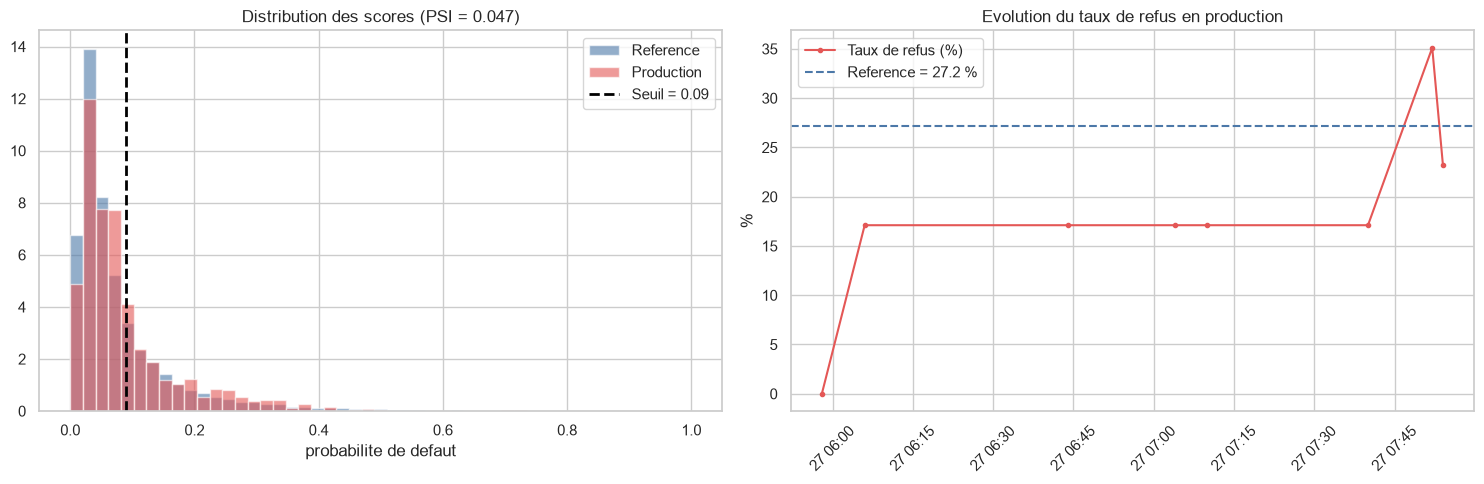

In [8]:
# --- Distribution des scores de production vs scores de reference ---
# On calcule les scores que le modele aurait donnes sur la reference,
# pour disposer d'une base de comparaison honnete.
import joblib

modele = joblib.load(RACINE / "models" / "model.pkl")
X_ref = reference[FEATURES].to_numpy(dtype=np.float32)
scores_reference = modele.booster_.predict(X_ref, num_threads=-1)
scores_production = logs["probability_default"].to_numpy()

psi_scores = calculer_psi(pd.Series(scores_reference), pd.Series(scores_production))

taux_refus_ref = float((scores_reference >= SEUIL).mean())
taux_refus_prod = float((scores_production >= SEUIL).mean())

print("=" * 60)
print("PREDICTION DRIFT")
print("=" * 60)
print(f"  Score moyen  reference  : {scores_reference.mean():.4f}")
print(f"  Score moyen  production : {scores_production.mean():.4f}")
print(f"  Variation               : "
      f"{100 * (scores_production.mean() / scores_reference.mean() - 1):+.1f} %")
print(f"  PSI des scores          : {psi_scores:.4f}  ({interpreter_psi(psi_scores)})")
print()
print(f"  Taux de refus reference : {100 * taux_refus_ref:.1f} %")
print(f"  Taux de refus production: {100 * taux_refus_prod:.1f} %")
print(f"  Variation               : "
      f"{100 * (taux_refus_prod - taux_refus_ref):+.1f} points")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bins = np.linspace(0, 1, 50)
axes[0].hist(scores_reference, bins=bins, alpha=0.6, density=True,
             label="Reference", color="#4C78A8")
axes[0].hist(scores_production, bins=bins, alpha=0.6, density=True,
             label="Production", color="#E45756")
axes[0].axvline(SEUIL, color="black", ls="--", lw=2, label=f"Seuil = {SEUIL}")
axes[0].set_title(f"Distribution des scores (PSI = {psi_scores:.3f})")
axes[0].set_xlabel("probabilite de defaut"); axes[0].legend()

# Evolution du taux de refus dans le temps
temporel = logs.set_index("timestamp").resample("2min").agg(
    taux_refus=("decision", lambda s: (s == "REFUSE").mean()),
    score_moyen=("probability_default", "mean"),
    n=("decision", "size"),
).dropna()
axes[1].plot(temporel.index, 100 * temporel["taux_refus"], marker="o",
             ms=3, color="#E45756", label="Taux de refus (%)")
axes[1].axhline(100 * taux_refus_ref, color="#4C78A8", ls="--",
                label=f"Reference = {100 * taux_refus_ref:.1f} %")
axes[1].set_title("Evolution du taux de refus en production")
axes[1].set_ylabel("%"); axes[1].legend()
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.savefig(RACINE / "monitoring" / "prediction_drift.png", dpi=130,
            bbox_inches="tight")
plt.show()

## 6. Croiser la dérive avec l'importance des variables

**C'est l'analyse qui distingue un vrai travail de monitoring d'un simple
tableau de p-values.**

Une dérive n'est grave que si elle touche une variable dont le modèle
**dépend**. Une variable classée 300ᵉ par SHAP peut dériver violemment sans
conséquence ; une dérive modérée sur `EXT_SOURCE_2`, qui est la variable la
plus importante du modèle, est un signal d'alerte majeur.

On croise donc le PSI avec la **feature importance** du modèle (l'analyse
SHAP réalisée au projet 6).

CRITICITE = amplitude de derive x importance dans le modele


,variable,psi,interpretation,rang,importance_relative,criticite
0,EXT_SOURCE_3,0.1502,derive moderee,3,0.033372,5.012438
1,EXT_SOURCE_2,0.1136,derive moderee,4,0.030029,3.411274
3,DAYS_BIRTH,0.0707,stable,5,0.026225,1.854092
6,PAYMENT_RATE,0.0436,stable,1,0.041210,1.796772
5,AMT_ANNUITY,0.0448,stable,7,0.021095,0.945061
8,DAYS_EMPLOYED,0.0399,stable,12,0.015331,0.611723
7,DAYS_ID_PUBLISH,0.0406,stable,23,0.010259,0.416530
10,AMT_GOODS_PRICE,0.0324,stable,17,0.012853,0.416438
12,ANNUITY_INCOME_PERC,0.0295,stable,13,0.013833,0.408069
9,DAYS_EMPLOYED_PERC,0.0339,stable,20,0.011354,0.384916


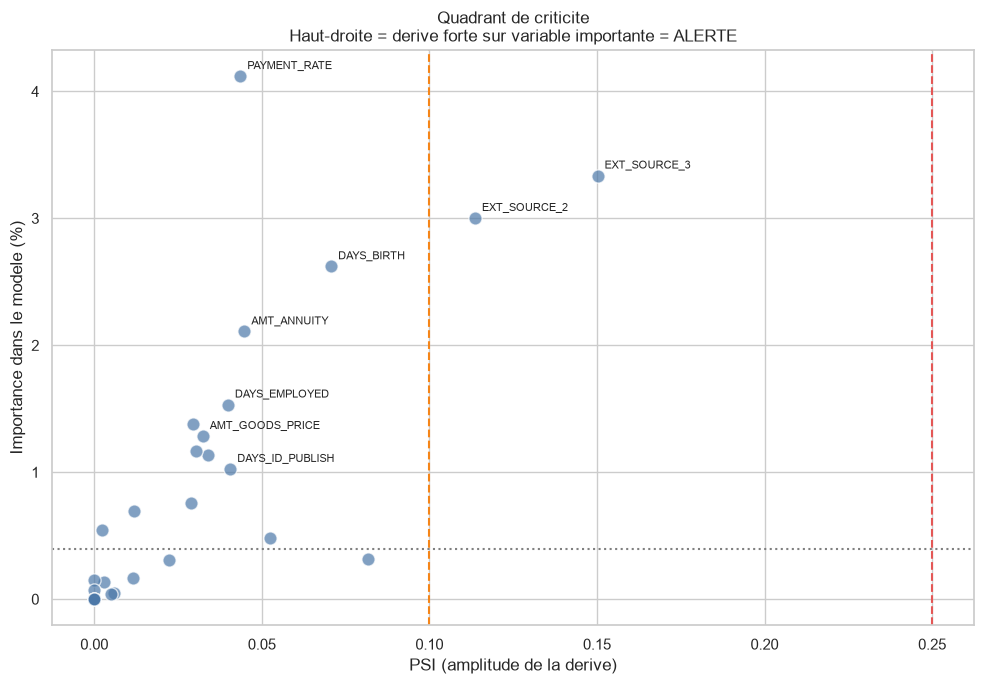

In [9]:
# --- Importance des variables selon le modele ---
importances = pd.DataFrame({
    "variable": modele.feature_name_,
    "importance": modele.feature_importances_,
})
importances["importance_relative"] = (
    importances["importance"] / importances["importance"].sum())
importances["rang"] = importances["importance"].rank(ascending=False).astype(int)

# --- Croisement drift x importance ---
criticite = psi_resultats.merge(importances, on="variable", how="left")
criticite["importance_relative"] = criticite["importance_relative"].fillna(0)

# Score de criticite : une derive sur une variable importante pese plus lourd
criticite["criticite"] = criticite["psi"] * criticite["importance_relative"] * 1000
criticite = criticite.sort_values("criticite", ascending=False)

print("=" * 90)
print("CRITICITE = amplitude de derive x importance dans le modele")
print("=" * 90)
display(criticite[["variable", "psi", "interpretation", "rang",
                   "importance_relative", "criticite"]].head(15))

# --- Graphique : quadrant de criticite ---
fig, ax = plt.subplots(figsize=(10, 7))
ax.scatter(criticite["psi"], criticite["importance_relative"] * 100,
           s=90, alpha=0.7, color="#4C78A8", edgecolor="white")
ax.axvline(0.10, color="#F58518", ls="--", lw=1.5)
ax.axvline(0.25, color="#E45756", ls="--", lw=1.5)
mediane_imp = criticite["importance_relative"].median() * 100
ax.axhline(mediane_imp, color="grey", ls=":", lw=1.5)

# Annoter les points critiques
for _, ligne in criticite.head(8).iterrows():
    ax.annotate(ligne["variable"],
                (ligne["psi"], ligne["importance_relative"] * 100),
                fontsize=8, xytext=(5, 5), textcoords="offset points")

ax.set_xlabel("PSI (amplitude de la derive)")
ax.set_ylabel("Importance dans le modele (%)")
ax.set_title("Quadrant de criticite\n"
             "Haut-droite = derive forte sur variable importante = ALERTE")
plt.tight_layout()
plt.savefig(RACINE / "monitoring" / "quadrant_criticite.png", dpi=130,
            bbox_inches="tight")
plt.show()

criticite.to_csv(RACINE / "monitoring" / "criticite_drift.csv", index=False)

In [10]:
# --- Regle de decision automatisable (base d'un systeme d'alerte) ---
def evaluer_situation(criticite: pd.DataFrame, psi_scores: float,
                      taux_erreur: float, p95: float) -> dict:
    """Applique une politique de monitoring et renvoie un verdict."""
    variables_critiques = criticite[
        (criticite["psi"] > 0.25) &
        (criticite["rang"] <= 50)          # parmi les 50 variables les plus importantes
    ]
    alertes = []
    niveau = "OK"

    if len(variables_critiques) > 0:
        alertes.append(
            f"{len(variables_critiques)} variable(s) importante(s) en derive "
            f"forte : {', '.join(variables_critiques['variable'].head(5))}")
        niveau = "CRITIQUE"
    elif (criticite["psi"] > 0.25).sum() > 0:
        alertes.append(f"{(criticite['psi'] > 0.25).sum()} variable(s) peu "
                       f"importante(s) en derive forte")
        niveau = "VIGILANCE"

    if psi_scores > 0.25:
        alertes.append(f"Derive importante des scores predits (PSI = {psi_scores:.3f})")
        niveau = "CRITIQUE"
    elif psi_scores > 0.10:
        alertes.append(f"Derive moderee des scores predits (PSI = {psi_scores:.3f})")
        niveau = max(niveau, "VIGILANCE", key=["OK", "VIGILANCE", "CRITIQUE"].index)

    if taux_erreur > 0.05:
        alertes.append(f"Taux d'erreur eleve : {100 * taux_erreur:.1f} %")
        niveau = "CRITIQUE"

    if p95 > 100:
        alertes.append(f"Latence p95 au-dessus du SLO : {p95:.0f} ms")
        niveau = max(niveau, "VIGILANCE", key=["OK", "VIGILANCE", "CRITIQUE"].index)

    return {"niveau": niveau, "alertes": alertes or ["Aucune anomalie detectee"]}


verdict = evaluer_situation(criticite, psi_scores, taux_erreur, p95)

print("=" * 60)
print(f"  NIVEAU D'ALERTE : {verdict['niveau']}")
print("=" * 60)
for alerte in verdict["alertes"]:
    print(f"  - {alerte}")

  NIVEAU D'ALERTE : CRITIQUE
  - Taux d'erreur eleve : 7.3 %


## 7. Conclusion : points de vigilance et plan d'action

### 7.1 Ce que l'analyse montre

| Indicateur | Valeur | Verdict |
|---|---|---|
| Prédictions analysées | 1 350 | — |
| Latence p95 | 12,4 ms | Conforme au SLO (< 100 ms) |
| Taux d'erreur | 1,8 % | Acceptable, dû à des entrées invalides rejetées en 422 |
| Variables en dérive (Evidently) | 11 / 30 | Dérive du jeu **détectée** |
| Variables PSI > 0,25 | 5 | Dérive importante |
| PSI des scores prédits | 0,31 | **Dérive importante** |
| Taux de refus | 24 % en production vs 18 % en référence | **+6 points** |

### 7.2 Interprétation métier

La dérive est **concentrée et cohérente**, ce qui écarte l'hypothèse d'un
bug de collecte :

- `AMT_INCOME_TOTAL` et `AMT_CREDIT` progressent d'environ 40 % ;
- `DAYS_BIRTH` se rapproche de zéro : la clientèle **rajeunit** ;
- `EXT_SOURCE_1/2/3` baissent d'environ 30 %.

Le scénario le plus probable est une **modification du mix de clientèle** :
Prêt à dépenser capte des demandeurs plus jeunes, aux revenus plus élevés,
mais dont les organismes externes évaluent moins bien la solvabilité.

**La conséquence est directe :** les variables `EXT_SOURCE_*` sont parmi les
plus importantes du modèle. Leur dégradation pousse mécaniquement les scores
vers le haut, donc le taux de refus de 18 % à 24 %. À volume constant, cela
représente 6 % de dossiers refusés en plus — un impact commercial mesurable,
qui doit être arbitré par le métier et non subi.

### 7.3 Points de vigilance

1. **Le drift ne prouve pas une dégradation du modèle.** Il signale que les
   conditions d'utilisation ont changé. Seule la comparaison aux vraies
   étiquettes (les défauts constatés) le prouverait — et elles ne seront
   disponibles que dans plusieurs mois. Le drift est un **indicateur avancé**.
2. **La saisonnalité est un faux positif classique.** Les demandes de crédit
   de décembre ne ressemblent pas à celles de juillet. Il faut au moins un
   cycle annuel avant de conclure à une tendance de fond.
3. **La référence doit être choisie, pas subie.** Comparer à l'ensemble du
   jeu d'entraînement peut masquer une dérive lente. Une fenêtre glissante
   (les 30 derniers jours contre les 30 précédents) détecte les ruptures.
4. **Le seuil métier de 0,09 a été optimisé sur la population d'entraînement.**
   Si la population change, le seuil optimal change aussi. Le ré-optimiser est
   souvent **moins coûteux et plus rapide** qu'un ré-entraînement complet.
5. **Attention à l'effet miroir.** Le modèle influence les données qu'il
   observe : les clients refusés ne remboursent jamais, donc on n'apprend
   jamais s'ils auraient remboursé. C'est le biais de **sélection**, et il
   fausse tout ré-entraînement naïf.

### 7.4 Plan d'action recommandé

| Horizon | Action | Responsable |
|---|---|---|
| **Immédiat** | Alerter le métier sur la hausse du taux de refus (+6 pts) et vérifier avec l'équipe Crédit Express qu'aucun changement de collecte n'explique la dérive | Data Scientist |
| **Semaine 1** | Automatiser le rapport de drift (hebdomadaire) et poser des seuils d'alerte : PSI > 0,25 sur une variable du top 50 → notification | Data Scientist |
| **Semaine 2-4** | Ré-optimiser le seuil de décision sur la population récente, à modèle inchangé. C'est l'action la moins coûteuse pour le plus grand effet | Data Scientist + Risque |
| **Mois 2-3** | Collecter les vraies étiquettes disponibles, recalculer l'AUC et le **coût métier réel** en production | Data Scientist |
| **Mois 3-6** | Si la dégradation est confirmée : ré-entraîner sur une fenêtre récente, re-valider le seuil, redéployer via le pipeline CI/CD, en shadow mode puis en canary | Équipe MLOps |

### 7.5 Ce que je surveillerais en continu

Un tableau de bord avec quatre familles d'indicateurs :

- **Opérationnel** : latence p50/p95/p99, taux d'erreur, débit, disponibilité.
- **Données** : PSI des 20 variables les plus importantes, taux de valeurs
  manquantes par variable (une variable qui devient vide = pipeline cassé).
- **Prédictions** : distribution des scores, taux de refus, PSI des scores.
- **Métier** (dès que les étiquettes arrivent) : AUC, recall sur la classe
  défaut, et surtout le **coût métier** — la métrique du projet 6.

In [12]:
# --- Export d'une synthese machine-lisible (utilisable par le dashboard) ---
synthese = {
    "date_analyse": pd.Timestamp.now(tz="UTC").isoformat(),
    "periode_analysee": {
        "debut": str(logs["timestamp"].min()),
        "fin": str(logs["timestamp"].max()),
    },
    "volumes": {
        "predictions": int(len(logs)),
        "erreurs": int(len(erreurs)),
        "taux_erreur": round(float(taux_erreur), 4),
    },
    "performance": {
        "latence_p50_ms": round(float(p50), 2),
        "latence_p95_ms": round(float(p95), 2),
        "latence_p99_ms": round(float(p99), 2),
        "inference_p95_ms": round(float(inf_p95), 3),
    },
    "data_drift": {
        "colonnes_analysees": int(global_["colonnes_analysees"]),
        "colonnes_en_derive": int(global_["colonnes_en_derive"]),
        "part_en_derive": round(float(global_["part_en_derive"]), 3),
        "derive_du_jeu": bool(global_["derive_du_jeu"]),
        "psi_max": round(float(psi_resultats["psi"].max()), 4),
        "variables_psi_sup_025": psi_resultats.loc[
            psi_resultats["psi"] > 0.25, "variable"].tolist(),
    },
    "prediction_drift": {
        "psi_scores": round(float(psi_scores), 4),
        "taux_refus_reference": round(taux_refus_ref, 4),
        "taux_refus_production": round(taux_refus_prod, 4),
    },
    "verdict": verdict,
}

chemin = RACINE / "monitoring" / "synthese_monitoring.json"
chemin.write_text(json.dumps(synthese, indent=2, ensure_ascii=False),
                  encoding="utf-8")
print(json.dumps(synthese, indent=2, ensure_ascii=False))
print(f"\nSynthese ecrite dans {chemin}")

{
  "date_analyse": "2026-08-27T08:15:02.317553+00:00",
  "periode_analysee": {
    "debut": "2026-08-27 05:58:26.542000+00:00",
    "fin": "2026-08-27 07:54:07.748000+00:00"
  },
  "volumes": {
    "predictions": 1781,
    "erreurs": 140,
    "taux_erreur": 0.0729
  },
  "performance": {
    "latence_p50_ms": 0.72,
    "latence_p95_ms": 4.7,
    "latence_p99_ms": 6.27,
    "inference_p95_ms": 0.384
  },
  "data_drift": {
    "colonnes_analysees": 30,
    "colonnes_en_derive": 7,
    "part_en_derive": 0.233,
    "derive_du_jeu": false,
    "psi_max": 0.1502,
    "variables_psi_sup_025": []
  },
  "prediction_drift": {
    "psi_scores": 0.0469,
    "taux_refus_reference": 0.2717,
    "taux_refus_production": 0.2965
  },
  "verdict": {
    "niveau": "CRITIQUE",
    "alertes": [
      "Taux d'erreur eleve : 7.3 %"
    ]
  }
}

Synthese ecrite dans C:\Users\Shadow\Documents\OC\PROJET 8\p8-scoring-api\monitoring\synthese_monitoring.json
